# Results and evidence audit

Verifies the raw inputs behind the figures and displays regenerated results. The external audit/ledger.md is the authoritative final audit; its status can change after this notebook executes.

In [1]:
from pathlib import Path
import json, csv, sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'src' / 'revllm').exists(), 'Execute with repository root as working directory'
sys.path.insert(0, str(ROOT / 'src'))
from revllm.data import digest_file
def read_final(path):
    result = json.loads(path.read_text())
    updates = [json.loads(line) for line in (path.parent/'metrics.jsonl').read_text().splitlines()]
    assert sum(row['valid_targets'] for row in updates if row['status']=='COMMITTED') == result['committed_targets']
    return result


In [2]:
table = ROOT/'results'/'runs.csv'
rows = list(csv.DictReader(table.open(newline='',encoding='utf-8'))) if table.exists() else []
full = [r for r in rows if r['run_id'][:1] in 'ABCDE' and r['committed_targets']=='50000000']
print({'verified_50m_runs':len(full), 'run_ids':[r['run_id'] for r in full]})

{'verified_50m_runs': 19, 'run_ids': ['A-1337', 'A-2027', 'B-1337', 'B-2027', 'C-1337', 'C-2027', 'D-1337', 'E-1337', 'A-L-2027', 'B-L-2027', 'C-L191-1337', 'C-L191-2027', 'E-L191-1337', 'A-L-1337', 'B-L-1337', 'D-L-1337', 'A-3141', 'B-3141', 'C-3141']}


In [3]:
provenance=json.loads((ROOT/'results/figures/figure_provenance.json').read_text())
for item in provenance['inputs']:
    assert digest_file(ROOT/item['path']) == item['sha256'], item['path']
print({'verified_figure_inputs':len(provenance['inputs']), 'main_campaign':provenance['main_campaign'], 'gaps':provenance['gaps']})

{'verified_figure_inputs': 89, 'main_campaign': 'locked', 'gaps': []}


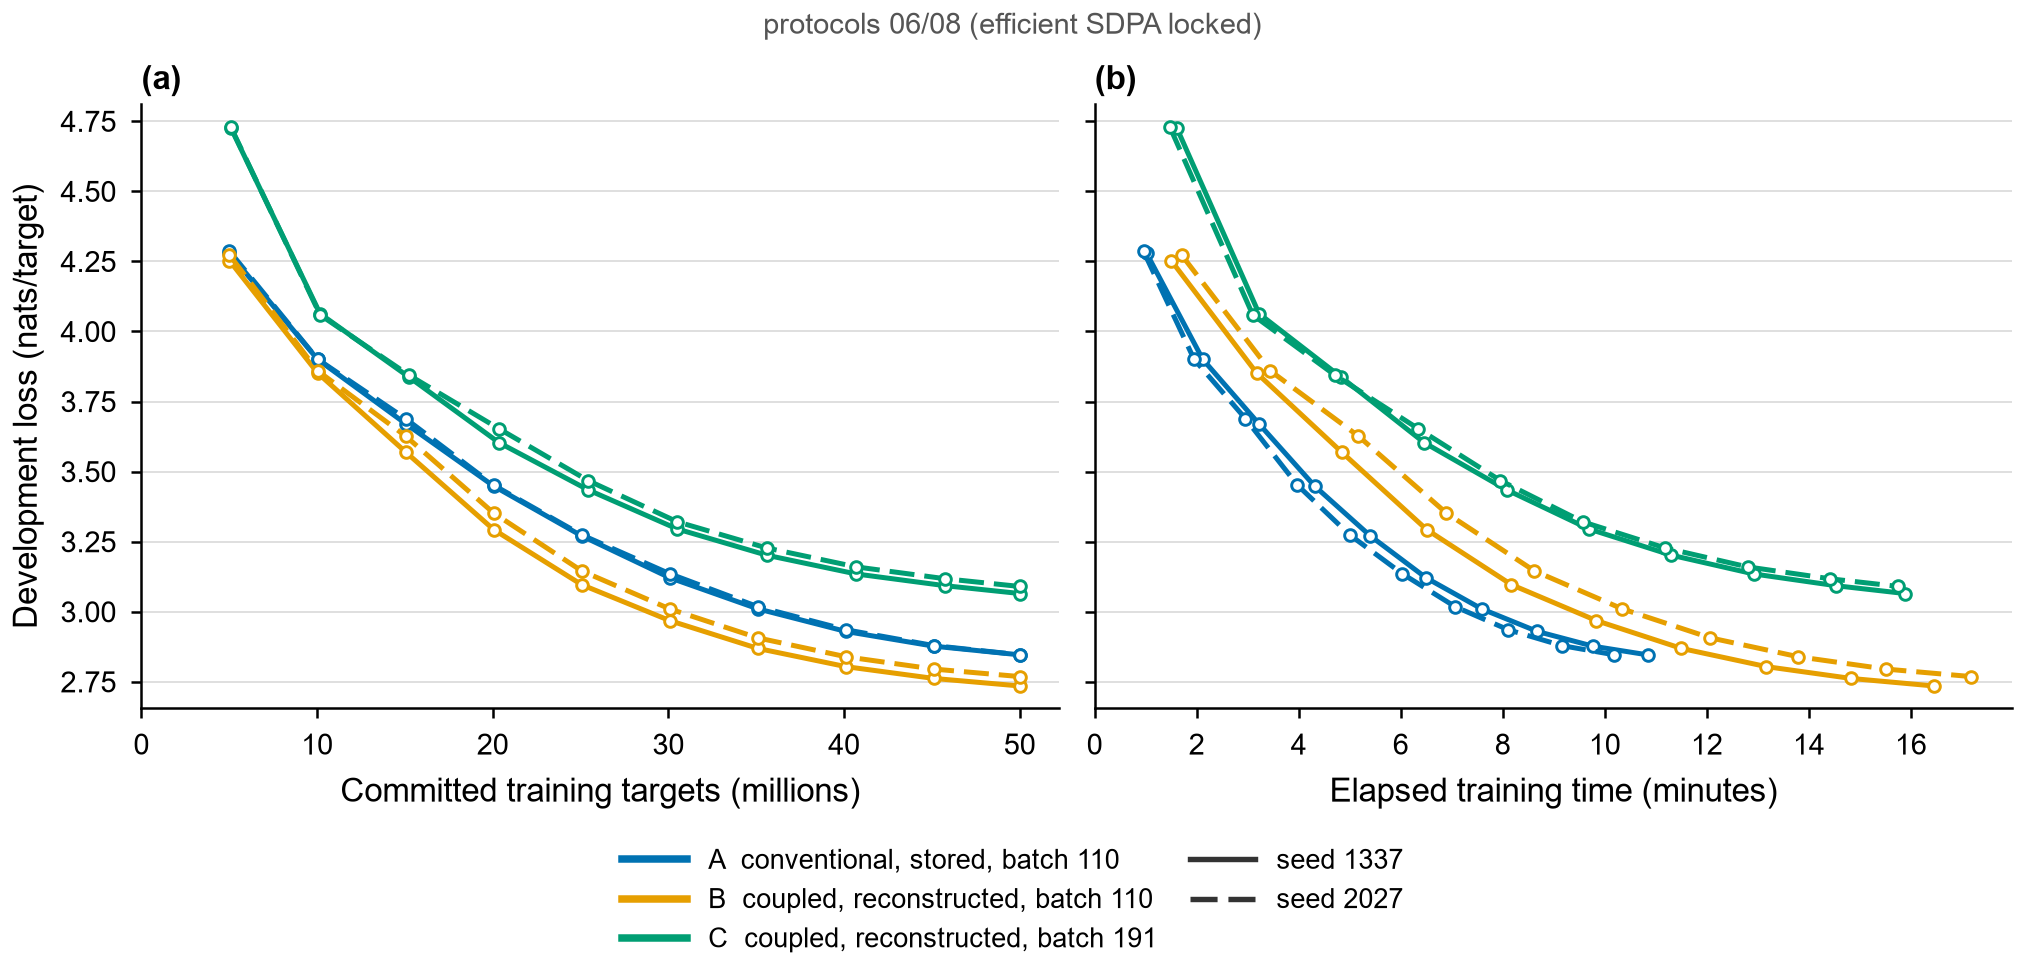

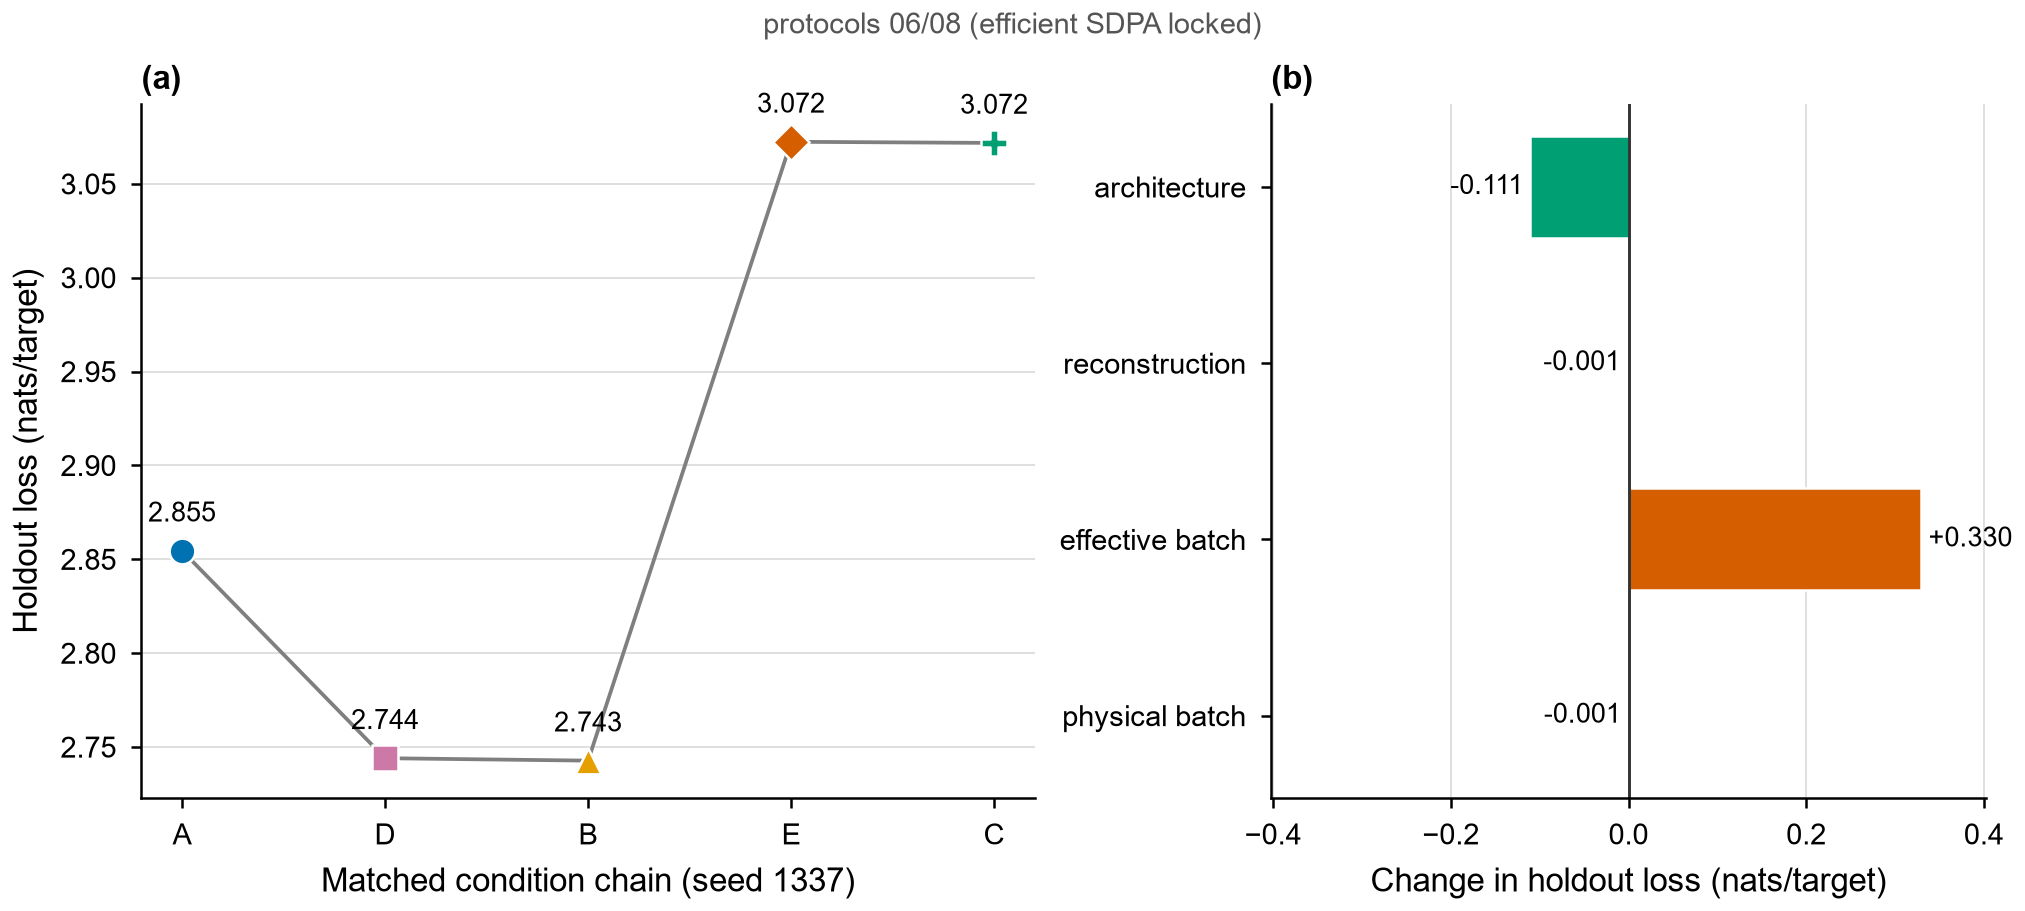

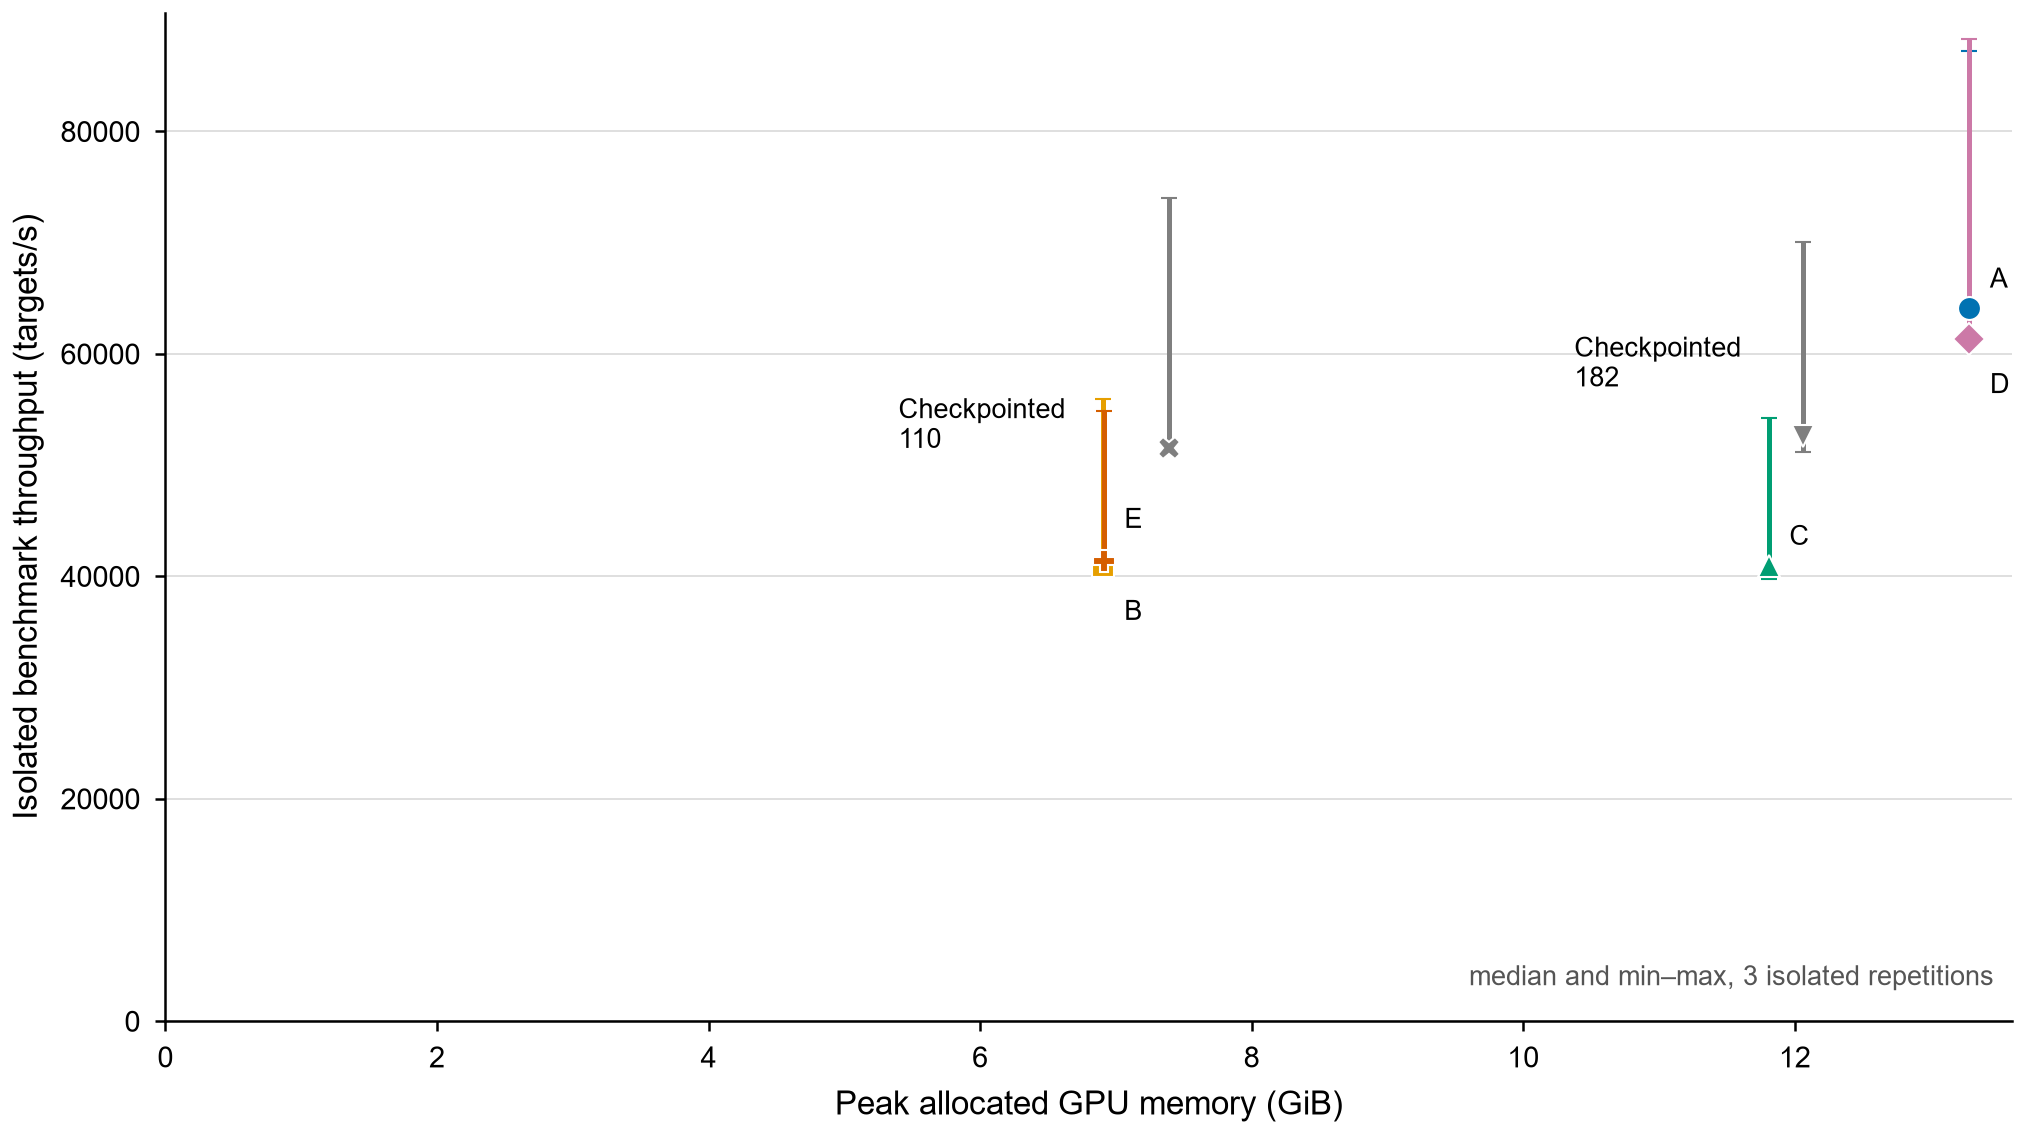

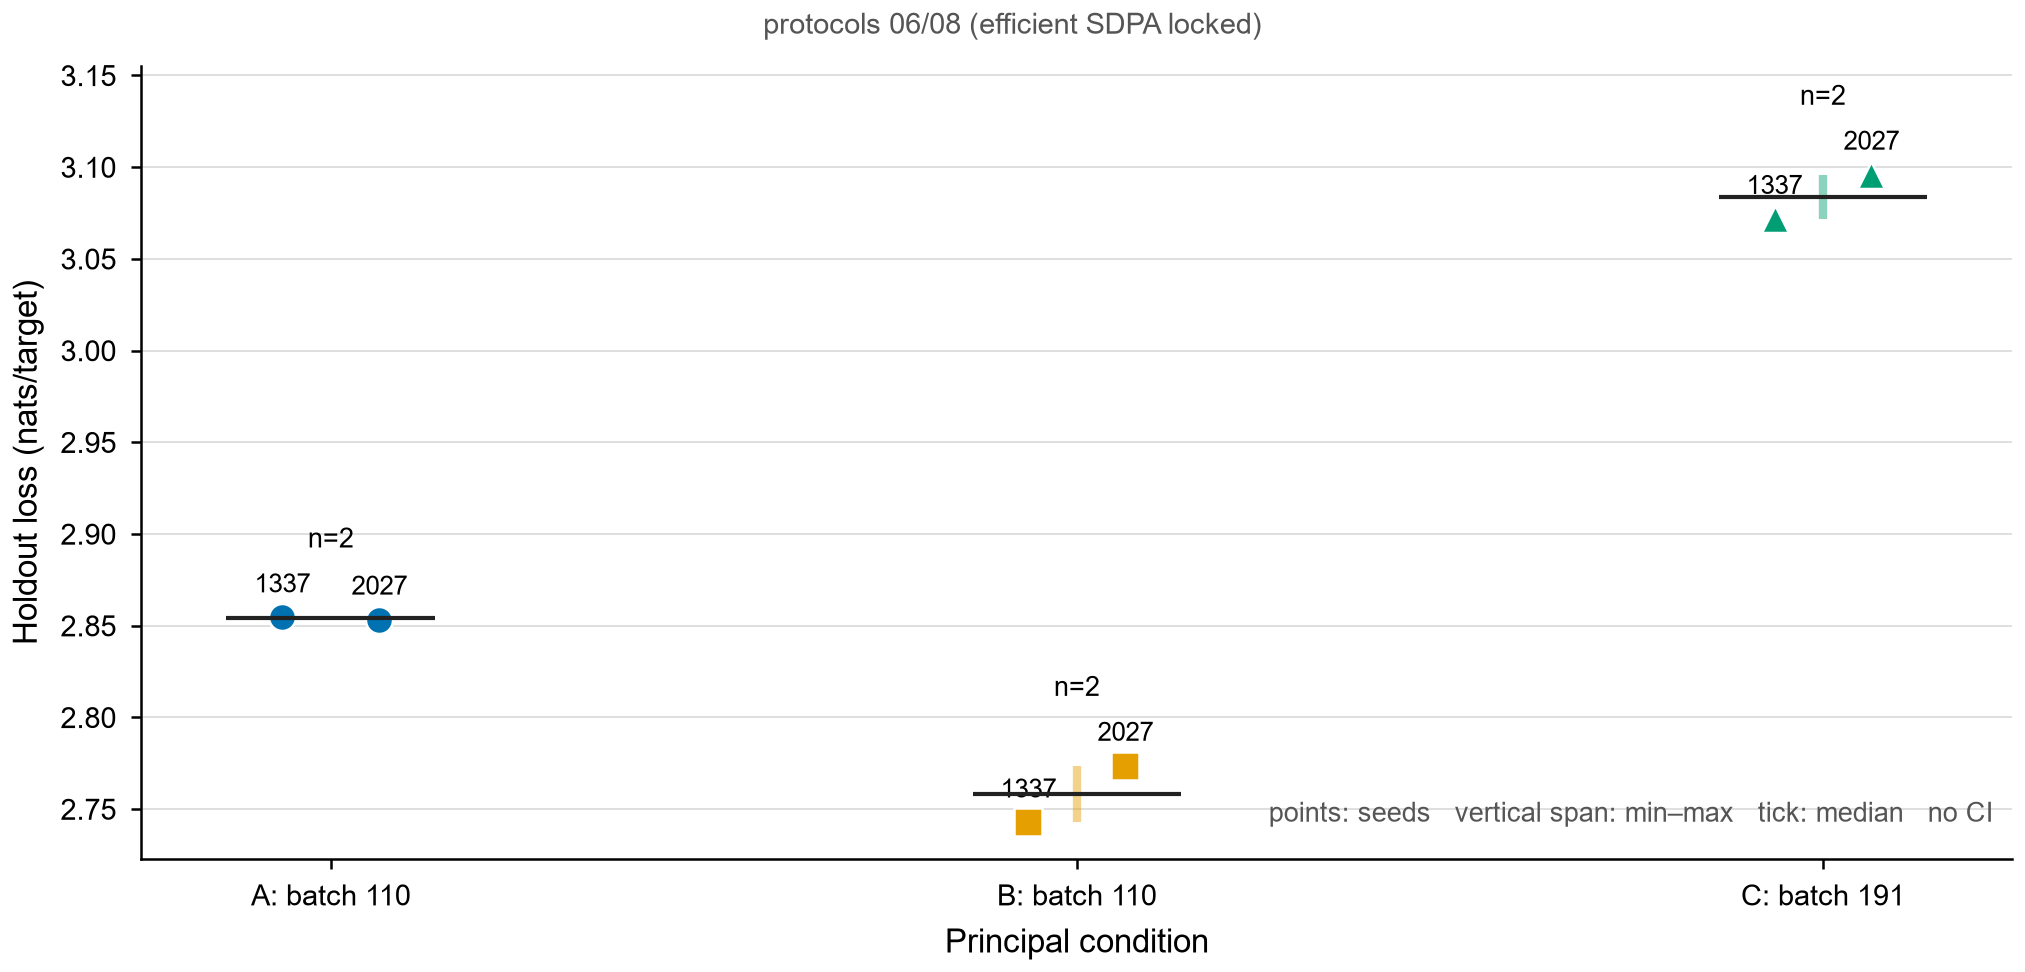

In [4]:
from IPython.display import Image, display
for name in ('development_loss_curves','causal_loss_chain_seed1337','memory_throughput','seed_variation_holdout'):
    display(Image(filename=str(ROOT/'results/figures'/f'{name}.png'),width=900))